# Métodos principales de escalado y _data leakage_

Esta libreta acompaña la presentación sobre métodos principales de escalado. El objetivo es que las diferencias entre métodos sean **visibles y comparables**, especialmente cuando existen valores atípicos (_outliers_).

Se ejemplifican:

1. **Normalización Min-Max**
2. **Estandarización Z-score**
3. **Escalado robusto**
4. Buenas prácticas para evitar **data leakage**
5. Un caso donde el _data leakage_ produce una diferencia clara en el desempeño del modelo

> Idea central: los parámetros del escalador —mínimos, máximos, medias, desviaciones estándar, medianas o IQR— deben calcularse **sólo con el conjunto de entrenamiento**.


## 1. Importación de librerías


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

np.random.seed(42)
pd.set_option("display.precision", 4)

## 2. Datos con diferencias de escala y valores atípicos

Para que la diferencia entre métodos sea más notoria, construiremos un conjunto de datos con:

- una variable de escala pequeña: `edad`
- una variable de escala grande: `salario`
- una variable con valores atípicos: `deuda`
- una etiqueta para identificar si la observación es típica u outlier

Los outliers hacen que **Min-Max Scaling** comprima muchos valores normales en una zona muy pequeña del intervalo \([0,1]\).


In [ ]:
# Datos típicos
datos_tipicos = pd.DataFrame(
    {
        "edad": [23, 25, 28, 31, 34, 37, 41, 45, 49, 53, 57, 61],
        "salario": [
            28000,
            32000,
            35000,
            39000,
            43000,
            47000,
            52000,
            58000,
            65000,
            72000,
            81000,
            90000,
        ],
        "deuda": [
            1500,
            2200,
            1800,
            2600,
            3100,
            2800,
            3600,
            4200,
            3900,
            4600,
            5200,
            5800,
        ],
        "tipo": "típico",
    }
)

# Valores atípicos fuertes
outliers = pd.DataFrame(
    {
        "edad": [66, 70],
        "salario": [250000, 1000000],
        "deuda": [80000, 250000],
        "tipo": "outlier",
    }
)

df = pd.concat([datos_tipicos, outliers], ignore_index=True)
df

,edad,salario,deuda,tipo
0,23,28000,1500,típico
1,25,32000,2200,típico
2,28,35000,1800,típico
3,31,39000,2600,típico
4,34,43000,3100,típico
5,37,47000,2800,típico
6,41,52000,3600,típico
7,45,58000,4200,típico
8,49,65000,3900,típico
9,53,72000,4600,típico


## 3. Aplicación de los métodos de escalado

Aplicaremos los tres métodos a las variables numéricas:

- `MinMaxScaler`
- `StandardScaler`
- `RobustScaler`

Después compararemos cómo transforma cada método los valores típicos y los outliers.


In [ ]:
features = ["edad", "salario", "deuda"]
X = df[features]

scalers = {
    "MinMax": MinMaxScaler(),
    "Z-score": StandardScaler(),
    "Robust": RobustScaler(),
}

scaled_dfs = {}

for nombre, scaler in scalers.items():
    X_scaled = scaler.fit_transform(X)
    scaled_dfs[nombre] = pd.DataFrame(
        X_scaled, columns=[f"{col}_{nombre}" for col in features]
    )

df_scaled = pd.concat([df, *scaled_dfs.values()], axis=1)
df_scaled

,edad,salario,deuda,tipo,edad_MinMax,salario_MinMax,deuda_MinMax,edad_Z-score,salario_Z-score,deuda_Z-score,edad_Robust,salario_Robust,deuda_Robust
0,23,28000,1500,típico,0.0000,0.0000,0.0000,-1.4284,-0.4360,-0.3847,-0.8247,-0.6968,-0.9375
1,25,32000,2200,típico,0.0426,0.0041,0.0028,-1.2942,-0.4197,-0.3740,-0.7423,-0.5935,-0.6458
2,28,35000,1800,típico,0.1064,0.0072,0.0012,-1.0929,-0.4075,-0.3801,-0.6186,-0.5161,-0.8125
3,31,39000,2600,típico,0.1702,0.0113,0.0044,-0.8916,-0.3912,-0.3678,-0.4948,-0.4129,-0.4792
4,34,43000,3100,típico,0.2340,0.0154,0.0064,-0.6902,-0.3749,-0.3601,-0.3711,-0.3097,-0.2708
5,37,47000,2800,típico,0.2979,0.0195,0.0052,-0.4889,-0.3587,-0.3647,-0.2474,-0.2065,-0.3958
6,41,52000,3600,típico,0.3830,0.0247,0.0085,-0.2205,-0.3383,-0.3524,-0.0825,-0.0774,-0.0625
7,45,58000,4200,típico,0.4681,0.0309,0.0109,0.0479,-0.3139,-0.3432,0.0825,0.0774,0.1875
8,49,65000,3900,típico,0.5532,0.0381,0.0097,0.3164,-0.2854,-0.3478,0.2474,0.2581,0.0625
9,53,72000,4600,típico,0.6383,0.0453,0.0125,0.5848,-0.2569,-0.3371,0.4124,0.4387,0.3542


## 4. Comparación visual: salario vs. deuda

En esta gráfica se observa el efecto de cada método sobre dos variables con escala grande y outliers.

Observa especialmente que:

- con **Min-Max**, los casos típicos quedan muy comprimidos cerca de cero;
- con **Z-score**, los outliers siguen influyendo, aunque menos que en Min-Max;
- con **RobustScaler**, los casos típicos quedan más separados porque el método usa mediana e IQR.


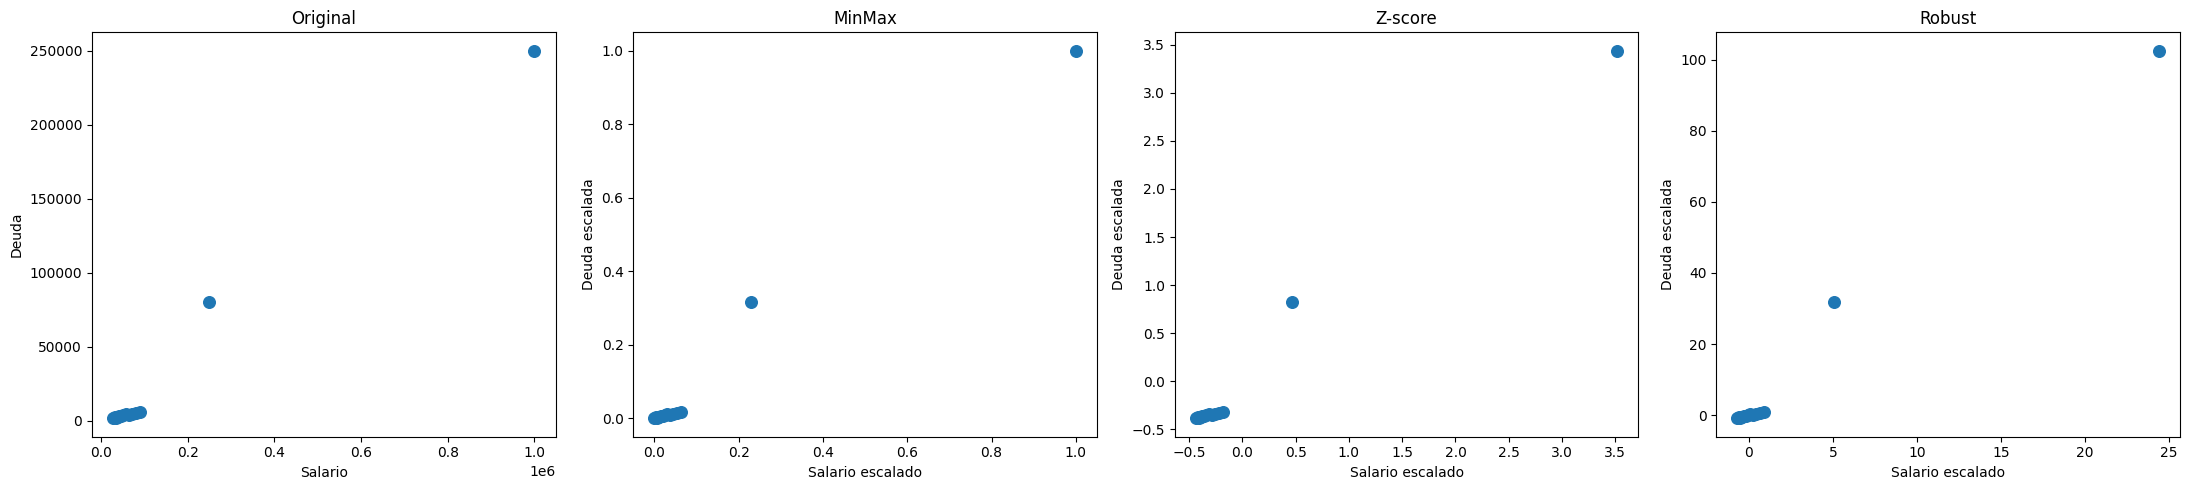

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Datos originales
axes[0].scatter(df["salario"], df["deuda"], s=70)
axes[0].set_title("Original")
axes[0].set_xlabel("Salario")
axes[0].set_ylabel("Deuda")

for ax, nombre in zip(axes[1:], scalers.keys()):
    ax.scatter(df_scaled[f"salario_{nombre}"], df_scaled[f"deuda_{nombre}"], s=70)
    ax.set_title(nombre)
    ax.set_xlabel("Salario escalado")
    ax.set_ylabel("Deuda escalada")

plt.tight_layout()
plt.show()

## 5. Comparación enfocada sólo en observaciones típicas

La gráfica anterior incluye outliers. Ahora veremos únicamente las observaciones típicas **después del escalado**.

Esto ayuda a notar cómo algunos métodos comprimen o conservan mejor las diferencias entre los casos normales.


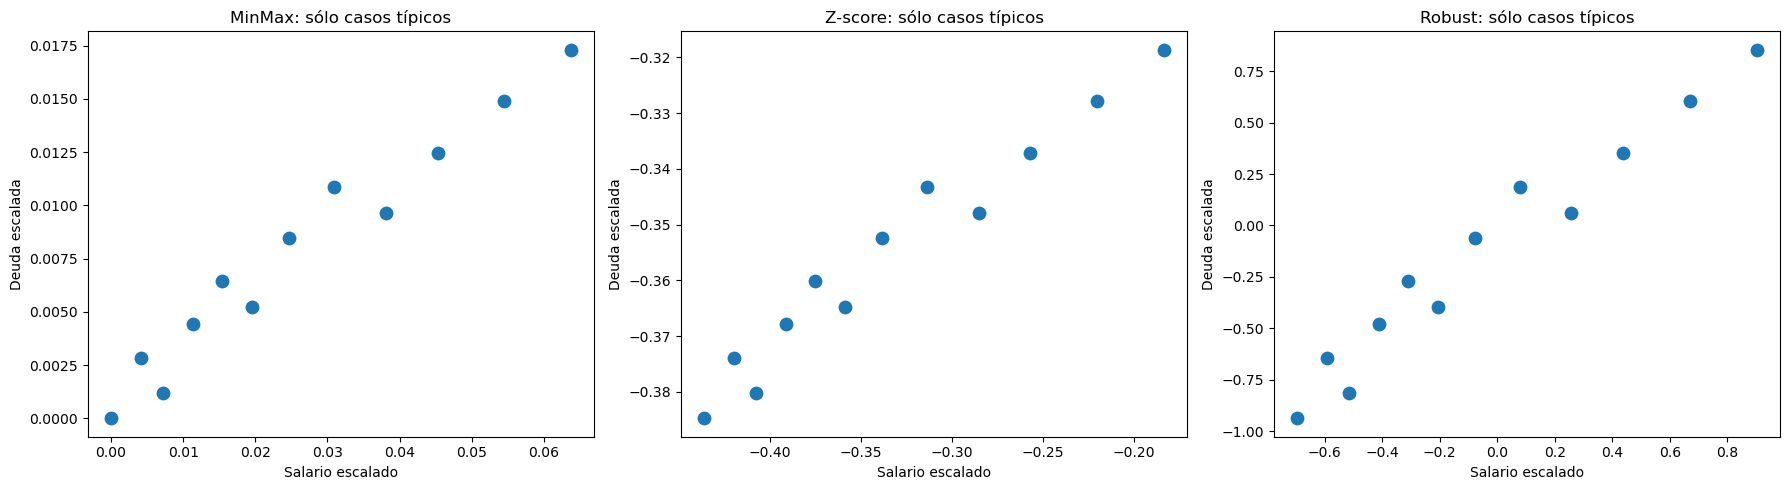

In [ ]:
tipicos = df_scaled[df_scaled["tipo"] == "típico"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, nombre in zip(axes, scalers.keys()):
    ax.scatter(tipicos[f"salario_{nombre}"], tipicos[f"deuda_{nombre}"], s=80)
    ax.set_title(f"{nombre}: sólo casos típicos")
    ax.set_xlabel("Salario escalado")
    ax.set_ylabel("Deuda escalada")

plt.tight_layout()
plt.show()

## 6. Comparación numérica de la compresión

Para hacer más evidente la diferencia, calcularemos el rango que ocupan **sólo los casos típicos** después de cada escalado.

Si el rango es muy pequeño, significa que los datos típicos quedaron comprimidos por la influencia de los outliers.


In [ ]:
resumen_compresion = []

for nombre in scalers.keys():
    for variable in ["salario", "deuda"]:
        valores = tipicos[f"{variable}_{nombre}"]
        resumen_compresion.append(
            {
                "método": nombre,
                "variable": variable,
                "mínimo_en_típicos": valores.min(),
                "máximo_en_típicos": valores.max(),
                "rango_en_típicos": valores.max() - valores.min(),
            }
        )

resumen_compresion = pd.DataFrame(resumen_compresion)
resumen_compresion

,método,variable,mínimo_en_típicos,máximo_en_típicos,rango_en_típicos
0,MinMax,salario,0.0000,0.0638,0.0638
1,MinMax,deuda,0.0000,0.0173,0.0173
2,Z-score,salario,-0.4360,-0.1837,0.2523
3,Z-score,deuda,-0.3847,-0.3186,0.0661
4,Robust,salario,-0.6968,0.9032,1.6000
5,Robust,deuda,-0.9375,0.8542,1.7917


## 7. Interpretación de los métodos

### Min-Max Scaling

Transforma los datos a un rango fijo, usualmente \([0,1]\).
Es útil cuando se requiere un rango acotado, pero puede ser muy sensible a outliers.

### StandardScaler / Z-score

Transforma los datos para que tengan media 0 y desviación estándar 1.
Es una opción común para algoritmos como regresión logística, SVM, PCA y redes neuronales.

### RobustScaler

Usa la mediana y el rango intercuartílico.
Suele ser preferible cuando existen valores atípicos importantes.


# Segunda parte: escalado correcto y _data leakage_

La regla práctica es:

1. Dividir primero los datos en entrenamiento y prueba.
2. Ajustar el escalador sólo con entrenamiento.
3. Transformar entrenamiento y prueba usando ese mismo escalador.

El error de _data leakage_ ocurre cuando ajustamos el escalador usando todo el conjunto de datos antes de dividir o cuando el conjunto de prueba influye de alguna manera en el preprocesamiento.


## 8. Ejemplo correcto: el escalador se ajusta sólo con entrenamiento


In [ ]:
# Generamos un problema sintético sencillo de clasificación
rng = np.random.default_rng(123)

n = 500
x1 = rng.normal(0, 1, n)
x2 = rng.normal(0, 30, n)

# La clase depende principalmente de x1, pero x2 tiene una escala mucho mayor
y = (x1 + rng.normal(0, 0.5, n) > 0).astype(int)

X = pd.DataFrame({"señal_principal": x1, "variable_gran_escala": x2})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

scaler_correcto = StandardScaler()
X_train_scaled = scaler_correcto.fit_transform(X_train)
X_test_scaled = scaler_correcto.transform(X_test)

modelo = KNeighborsClassifier(n_neighbors=7)
modelo.fit(X_train_scaled, y_train)

pred_correcto = modelo.predict(X_test_scaled)
accuracy_correcto = accuracy_score(y_test, pred_correcto)

print(f"Accuracy con escalado correcto: {accuracy_correcto:.3f}")

Accuracy con escalado correcto: 0.787


## 9. Forma recomendada: `Pipeline`


In [ ]:
pipeline = Pipeline(
    [("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=7))]
)

pipeline.fit(X_train, y_train)
pred_pipeline = pipeline.predict(X_test)

print(f"Accuracy usando Pipeline: {accuracy_score(y_test, pred_pipeline):.3f}")

Accuracy usando Pipeline: 0.787


## 10. Ejemplo de _data leakage_ con escalado

### Diseño del ejemplo

Crearemos un conjunto de entrenamiento y prueba con una diferencia intencional:

- En entrenamiento, la variable `ruido` tiene un rango moderado.
- En prueba, la variable `ruido` tiene un rango mucho más amplio.
- La clase depende de `señal`, no de `ruido`.

Usaremos **KNN**, un algoritmo basado en distancias. Si el escalador se ajusta incorrectamente con todo el dataset, el modelo “ve” indirectamente el rango del conjunto de prueba y reduce artificialmente el peso de la variable ruidosa. Eso puede inflar el desempeño.


In [ ]:
rng = np.random.default_rng(1970)

n_train = 80
n_test = 200

# Entrenamiento
y_train_leak_demo = rng.integers(0, 2, n_train)
X_train_leak_demo = pd.DataFrame(
    {
        # Señal útil: distingue parcialmente las clases
        "señal": rng.normal(y_train_leak_demo * 0.25, 0.15, n_train),
        # Ruido: no está relacionado con la clase
        "ruido": rng.normal(0, 1, n_train),
    }
)

# Prueba
y_test_leak_demo = rng.integers(0, 2, n_test)
X_test_leak_demo = pd.DataFrame(
    {
        "señal": rng.normal(y_test_leak_demo * 0.25, 0.15, n_test),
        # Ruido con rango mucho más grande en prueba
        "ruido": rng.normal(0, 20, n_test),
    }
)

print("Rango de la variable ruido en entrenamiento:")
print(X_train_leak_demo["ruido"].agg(["min", "max"]))

print("\nRango de la variable ruido en prueba:")
print(X_test_leak_demo["ruido"].agg(["min", "max"]))

Rango de la variable ruido en entrenamiento:
min   -2.0616
max    2.3355
Name: ruido, dtype: float64

Rango de la variable ruido en prueba:
min   -47.9749
max    57.0458
Name: ruido, dtype: float64


### 10.1 Procedimiento correcto: ajustar el escalador sólo con entrenamiento


In [ ]:
scaler_correcto = MinMaxScaler()

X_train_correcto = scaler_correcto.fit_transform(X_train_leak_demo)
X_test_correcto = scaler_correcto.transform(X_test_leak_demo)

knn_correcto = KNeighborsClassifier(n_neighbors=21)
knn_correcto.fit(X_train_correcto, y_train_leak_demo)

pred_correcto = knn_correcto.predict(X_test_correcto)
acc_correcto = accuracy_score(y_test_leak_demo, pred_correcto)

print(f"Accuracy SIN data leakage: {acc_correcto:.3f}")

Accuracy SIN data leakage: 0.440


### 10.2 Procedimiento incorrecto: ajustar el escalador con entrenamiento + prueba

Este procedimiento es incorrecto porque el escalador usa información del conjunto de prueba para calcular los mínimos y máximos.


In [ ]:
X_todo = pd.concat([X_train_leak_demo, X_test_leak_demo], ignore_index=True)

scaler_leaky = MinMaxScaler()
X_todo_leaky = scaler_leaky.fit_transform(X_todo)

X_train_leaky = X_todo_leaky[:n_train]
X_test_leaky = X_todo_leaky[n_train:]

knn_leaky = KNeighborsClassifier(n_neighbors=21)
knn_leaky.fit(X_train_leaky, y_train_leak_demo)

pred_leaky = knn_leaky.predict(X_test_leaky)
acc_leaky = accuracy_score(y_test_leak_demo, pred_leaky)

print(f"Accuracy CON data leakage: {acc_leaky:.3f}")

Accuracy CON data leakage: 0.820


### 10.3 Comparación directa


In [ ]:
comparacion_leakage = pd.DataFrame(
    {
        "escenario": [
            "Correcto: scaler fit sólo en train",
            "Incorrecto: scaler fit en train + test",
        ],
        "accuracy": [acc_correcto, acc_leaky],
    }
)

comparacion_leakage["diferencia_vs_correcto"] = (
    comparacion_leakage["accuracy"] - acc_correcto
)

comparacion_leakage

,escenario,accuracy,diferencia_vs_correcto
0,Correcto: scaler fit sólo en train,0.44,0.00
1,Incorrecto: scaler fit en train + test,0.82,0.38


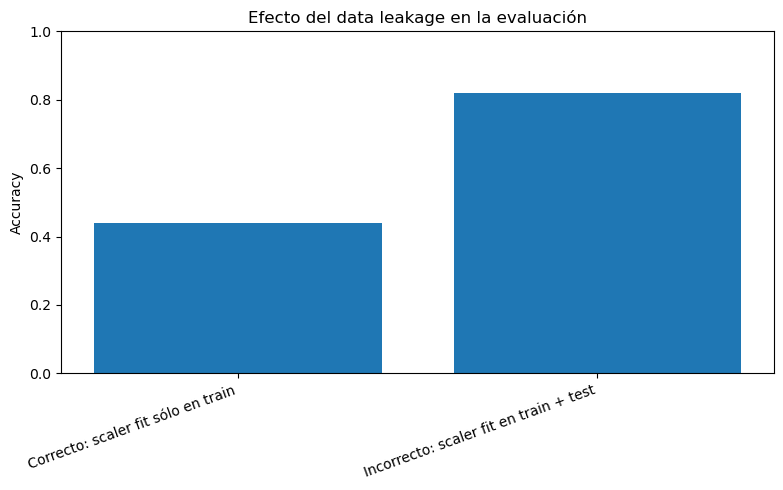

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(comparacion_leakage["escenario"], comparacion_leakage["accuracy"])
plt.ylabel("Accuracy")
plt.title("Efecto del data leakage en la evaluación")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Otro ejemplo


En este ejemplo se ve que una técnica como acotar por una cantidad también debe estar restringida sólo al conjunto de entrenamiento cuando este acotamiento depende de los datos (como en el caso de los outliers, IQR, z-score)

Para mostrarlo suponemos que tenemos un dataset de dos clases y simulamos lo que pasaría si volvemos a calcular el cuantil con los datos de prueba


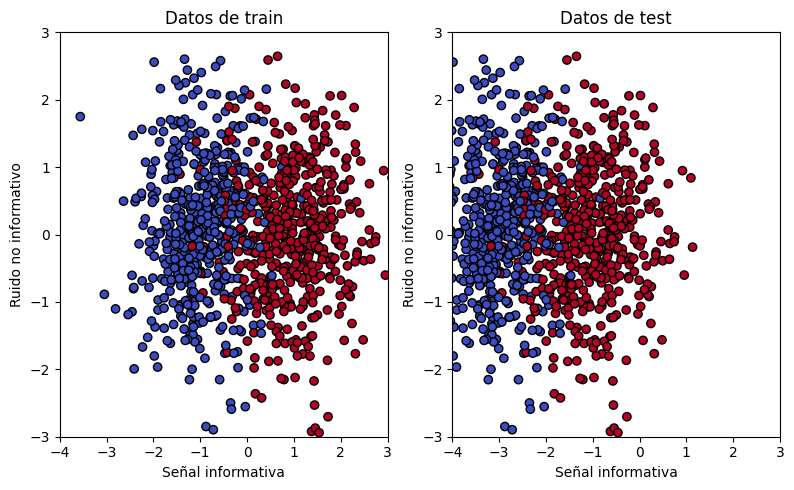

In [183]:
from sklearn.svm import SVC
from sklearn.datasets import make_classification

X_train, y_train = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_clusters_per_class=1,
    shift=[0, 0],
    random_state=42,
)


outlier_percentile_x = 0.90

x_limite = np.percentile(X_train[:, 0], outlier_percentile_x * 100)

X_test = X_train.copy()
X_test[:, 0] = X_test[:, 0] - 2
X_test[X_test[:, 0] >= x_limite] = x_limite



fig, ax = plt.subplots(figsize=(8, 5), ncols=2)
ax[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", edgecolor="k")
ax[0].set_title("Datos de train")
ax[0].set_xlabel("Señal informativa")
ax[0].set_ylabel("Ruido no informativo")
ax[0].set_xlim(-4, 3)
ax[0].set_ylim(-3, 3)
ax[1].scatter(
    X_test[:, 0], X_test[:, 1], c=y_train, cmap="coolwarm", edgecolor="k"
)
ax[1].set_title("Datos de test")
ax[1].set_xlabel("Señal informativa")
ax[1].set_xlim(-4, 3)
ax[1].set_ylabel("Ruido no informativo")
ax[1].set_ylim(-3, 3)
plt.tight_layout()
plt.show()

Entrenamos un modelo para separar las clases después de haber acotado los valores

In [ ]:
X_train_acotado = X_train.copy()
X_train_acotado[X_train_acotado[:, 0] >= x_limite] = x_limite

svc = SVC(kernel="linear")
svc.fit(X_train_acotado, y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


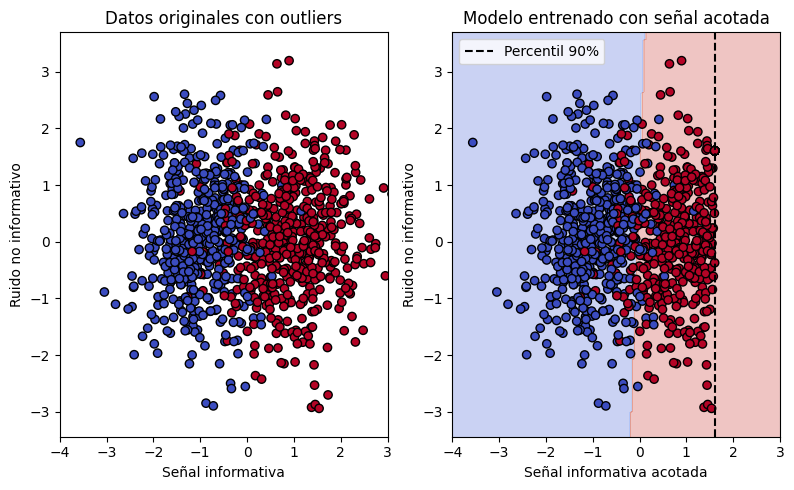

In [ ]:

# Esto para graficar la frontera de decisión del SVCs
x_min, x_max = X_train_acotado[:, 0].min() - 5, X_train_acotado[:, 0].max() + 2
y_min, y_max = X_train_acotado[:, 1].min() - 0.5, X_train_acotado[:, 1].max() + 0.5
xx_s, yy_s = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z_s = svc.predict(np.c_[xx_s.ravel(), yy_s.ravel()]).reshape(xx_s.shape)

fig, ax = plt.subplots(figsize=(8, 5), ncols=2)
ax[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", edgecolor="k")
ax[0].set_title("Datos originales con outliers")
ax[0].set_xlabel("Señal informativa")
ax[0].set_ylabel("Ruido no informativo")
ax[0].set_xlim(-4, 3)
ax[0].set_ylim(y_min, y_max)
ax[1].contourf(xx_s, yy_s, Z_s, alpha=0.3, cmap="coolwarm")
ax[1].scatter(
    X_train_acotado[:, 0], X_train_acotado[:, 1], c=y_train, cmap="coolwarm", edgecolor="k"
)
ax[1].set_title("Modelo entrenado con señal acotada")
ax[1].set_xlabel("Señal informativa acotada")
ax[1].set_xlim(-4, 3)
ax[1].set_ylabel("Ruido no informativo")
ax[1].axvline(
    x=x_limite,
    color="k",
    linestyle="--",
    label=f"Percentil {outlier_percentile_x*100:.0f}%",
)
ax[1].legend()
ax[1].set_ylim(y_min, y_max)
plt.tight_layout()
plt.show()

In [ ]:
x_limite_nuevo = np.percentile(X_test[:, 0], outlier_percentile_x * 100)

X_test_acotado = X_test.copy()
X_test_acotado[X_test_acotado[:, 0] >= x_limite_nuevo] = x_limite_nuevo

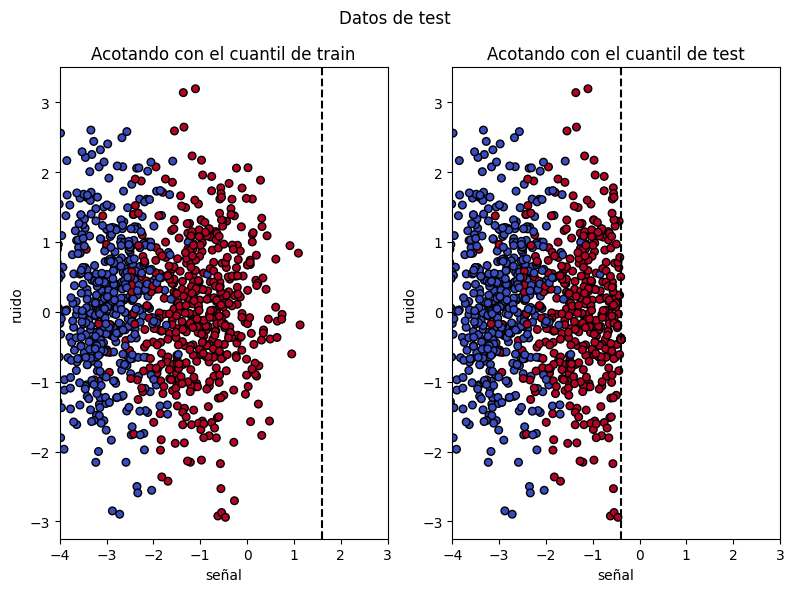

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6), nrows=1, ncols=2)
plt.suptitle("Datos de test")
ax[0].scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_train,
    cmap="coolwarm",
    edgecolor="k",
    s=30,
)
ax[0].set_xlabel("señal")
ax[0].set_xlim(-4, 3)
ax[0].set_ylabel("ruido")
ax[0].axvline(x_limite, color="k", linestyle="--", label="superficie de decisión")
ax[0].set_title("Acotando con el cuantil de train")
ax[1].scatter(
    X_test_acotado[:, 0],
    X_test_acotado[:, 1],
    c=y_train,
    cmap="coolwarm",
    edgecolor="k",
    s=30,
)
ax[1].set_xlim(-4, 3)
ax[1].set_xlabel("señal")
ax[1].axvline(x_limite_nuevo, color="k", linestyle="--", label="superficie de decisión")
ax[1].set_ylabel("ruido")
ax[1].set_title("Acotando con el cuantil de test")
plt.tight_layout()
plt.show()

Cuando entrenamos con el modelo habiendo acotado los


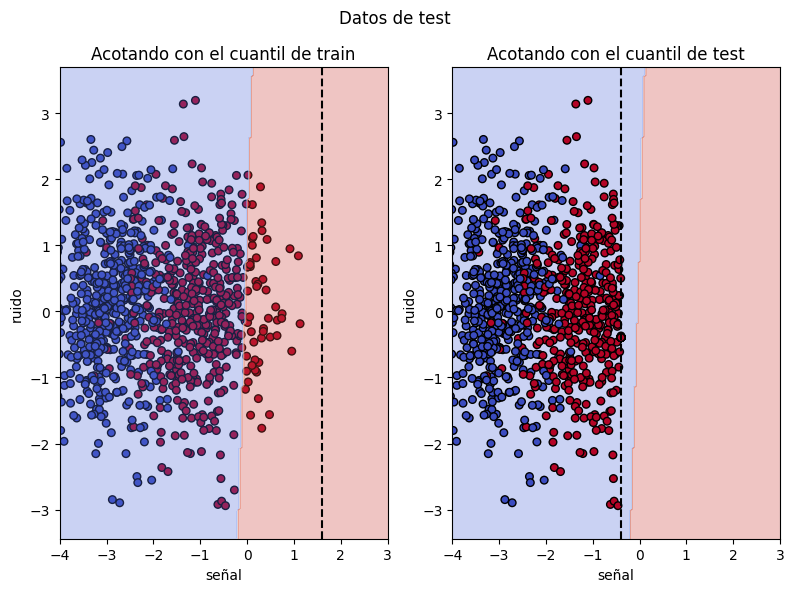

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6), nrows=1, ncols=2)
plt.suptitle("Datos de test")
ax[0].scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_train,
    cmap="coolwarm",
    edgecolor="k",
    s=30,
)
ax[0].contourf(xx_s, yy_s, Z_s, alpha=0.3, cmap="coolwarm")
ax[0].set_xlabel("señal")
ax[0].set_xlim(-4, 3)
ax[0].set_ylabel("ruido")
ax[0].axvline(x_limite, color="k", linestyle="--", label="superficie de decisión")
ax[0].set_title("Acotando con el cuantil de train")
ax[1].contourf(xx_s, yy_s, Z_s, alpha=0.3, cmap="coolwarm")
ax[1].scatter(
    X_test_acotado[:, 0],
    X_test_acotado[:, 1],
    c=y_train,
    cmap="coolwarm",
    edgecolor="k",
    s=30,
)
ax[1].set_xlim(-4, 3)
ax[1].set_xlabel("señal")
ax[1].axvline(x_limite_nuevo, color="k", linestyle="--", label="superficie de decisión")
ax[1].set_ylabel("ruido")
ax[1].set_title("Acotando con el cuantil de test")
plt.tight_layout()
plt.show()

# Descomposición y agregación de datos


Construimos un ejemplo de fechas y temperatura para mostrar cómo estas transformaciones nos pueden ayudar a obtener features informativos de los datos

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

dates = pd.date_range(start='2015-01-01', end='2024-12-31', freq='D')
df_raw = pd.DataFrame({'Timestamp': dates})

trend = (df_raw['Timestamp'].dt.year - 2015 + df_raw['Timestamp'].dt.dayofyear / 365.25) * 0.8

seasonality = -15 * np.cos((df_raw['Timestamp'].dt.dayofyear - 15) * 2 * np.pi / 365.25)

noise = np.random.normal(0, 4.0, len(dates))

df_raw['Temp_Daily'] = 15 + trend + seasonality + noise

df_raw

,Timestamp,Temp_Daily
0,2015-01-01,2.4220
1,2015-01-02,-0.1752
2,2015-01-03,2.9158
3,2015-01-04,6.3686
4,2015-01-05,-0.7043
...,...,...
3648,2024-12-27,11.8575
3649,2024-12-28,6.9262
3650,2024-12-29,10.2117
3651,2024-12-30,10.7158


In [ ]:
df_raw['Year'] = df_raw['Timestamp'].dt.year
df_raw['Month_Num'] = df_raw['Timestamp'].dt.month

df = df_raw.groupby(['Year', 'Month_Num'])['Temp_Daily'].mean().reset_index()
df.rename(columns={'Temp_Daily': 'Temp'}, inplace=True)
df['Plot_Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month_Num'].astype(str) + '-15')

In [210]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig_pre = make_subplots(rows=1, cols=2, subplot_titles=("Malla de datos: año y mes", "Serie de tiempo: Ruido diario vs. Promedio mensual"), column_widths=[0.4, 0.6])

heatmap_data = df.pivot(index='Month_Num', columns='Year', values='Temp')
fig_pre.add_trace(go.Heatmap(
    z=heatmap_data.values, x=heatmap_data.columns, y=heatmap_data.index,
    colorscale='RdBu_r', colorbar=dict(title="Temp °C", x=0.38)
), row=1, col=1)

fig_pre.add_trace(go.Scatter(
    x=df_raw['Timestamp'], y=df_raw['Temp_Daily'], mode='lines',
    line=dict(color='gray', width=1), opacity=0.25, name='Lecturas diarias'
), row=1, col=2)

fig_pre.add_trace(go.Scatter(
    x=df['Plot_Date'], y=df['Temp'], mode='lines+markers',
    line=dict(color='black', width=2), marker=dict(size=6, color='black'), name='Promedio mensual'
), row=1, col=2)

fig_pre.update_layout(title_text="Visualización de los datos", height=500, template='plotly_white')
fig_pre.update_yaxes(title_text="Mes (1-12)", tickmode='linear', tick0=1, dtick=1, row=1, col=1)
# fig_pre.update_yaxes(title_text="Temperature (°C)", row=1, col=2)
fig_pre.show()


In [ ]:
X = df[['Year', 'Month_Num']]
y = df['Temp']

tree_model = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_model.fit(X, y)
df['Temp_Pred'] = tree_model.predict(X)

mse = mean_squared_error(y, df['Temp_Pred'])
r2 = r2_score(y, df['Temp_Pred'])

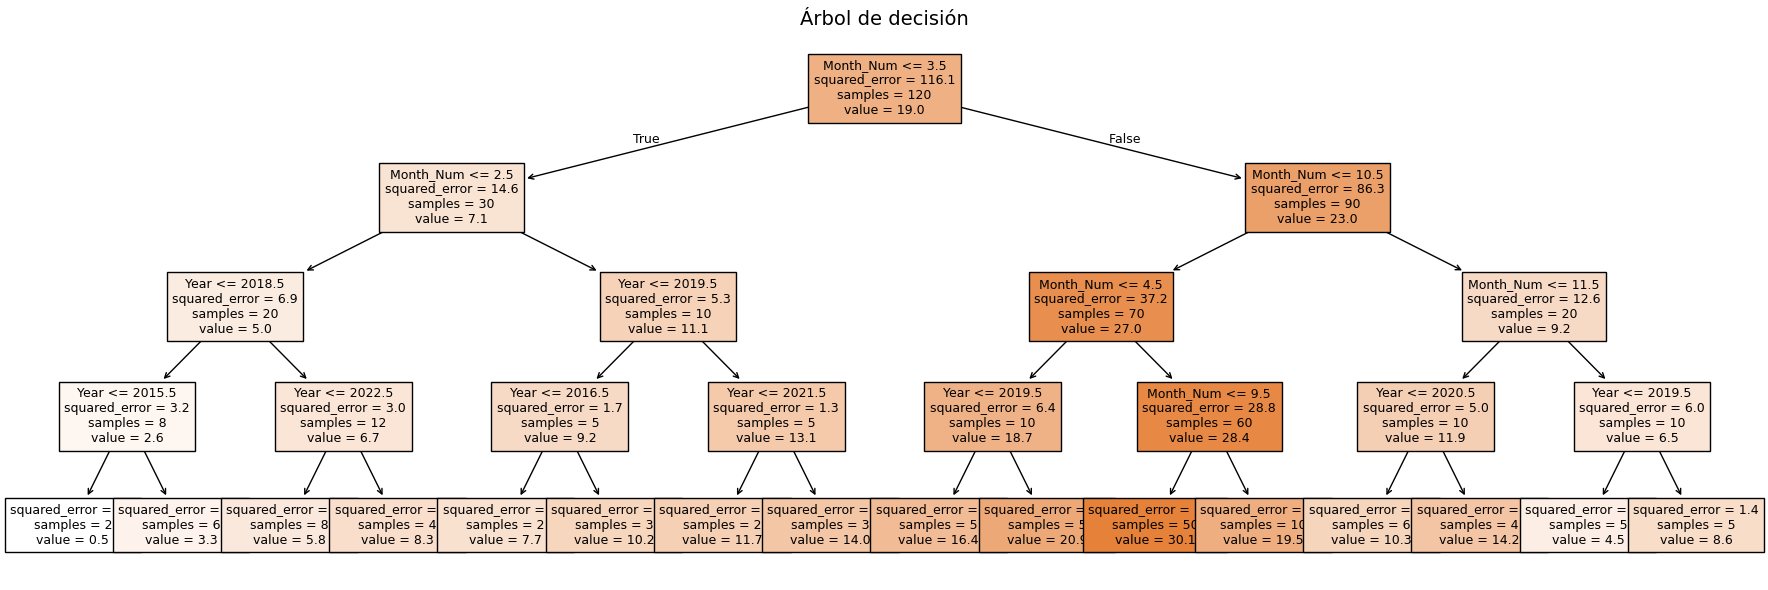

In [ ]:
plt.figure(figsize=(18, 6))
plot_tree(tree_model, feature_names=X.columns, filled=True, precision=1, fontsize=9)
plt.title("Árbol de decisión", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
fig_post = make_subplots(rows=1, cols=2, 
                         subplot_titles=(f" Frontera de decisión (Bloques discretos)<br>R2: {r2:.3f} | MSE: {mse:.2f}", 
                                         "Reconstrucción de serie de tiempo"), 
                         column_widths=[0.45, 0.55])

xx_year = np.linspace(2014.5, 2024.5, 300)
yy_month = np.linspace(0.5, 12.5, 300)
xx, yy = np.meshgrid(xx_year, yy_month)
Z = tree_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig_post.add_trace(go.Heatmap(
    x=xx_year, y=yy_month, z=Z, colorscale='RdBu_r', opacity=0.7, hoverinfo='skip', showscale=False
), row=1, col=1)

fig_post.add_trace(go.Scatter(
    x=df['Year'], y=df['Month_Num'], mode='markers',
    marker=dict(size=10, color=df['Temp'], colorscale='RdBu_r', line=dict(color='black', width=1.5)),
    text=df['Temp'].round(1).astype(str) + ' °C', hoverinfo='text+x+y', name='Datos reales'
), row=1, col=1)

fig_post.add_trace(go.Scatter(
    x=df['Plot_Date'], y=df['Temp'], mode='lines+markers',
    line=dict(color='black', width=2, dash='dot'), marker=dict(size=6), name='Promedio mensual real'
), row=1, col=2)

fig_post.add_trace(go.Scatter(
    x=df['Plot_Date'], y=df['Temp_Pred'], mode='lines',
    line=dict(color='red', width=3, shape='hv'), 
    name='Predicción del árbol (bloques)'
), row=1, col=2)

fig_post.update_layout(title_text=" Resultados del modelo", height=500, template='plotly_white')
fig_post.update_yaxes(title_text="Mes (1-12)", tickmode='linear', tick0=1, dtick=1, row=1, col=1)
fig_post.update_yaxes(title_text="Temperatura (°C)", row=1, col=2)
fig_post.show()




# Combinaciones polinomiales con sklearn

In [235]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

df = pd.DataFrame({
    'length': [10, 20, 15],
    'width': [5, 10, 10],
    'weight': [1.5, 3.0, 2.2]
})

poly = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)

interaction_matrix = poly.fit_transform(df)

feature_names = poly.get_feature_names_out(df.columns)

df_interactions = pd.DataFrame(interaction_matrix, columns=feature_names)

df_interactions

,length,width,weight,length width,length weight,width weight,length width weight
0,10.0,5.0,1.5,50.0,15.0,7.5,75.0
1,20.0,10.0,3.0,200.0,60.0,30.0,600.0
2,15.0,10.0,2.2,150.0,33.0,22.0,330.0


# Automated Feature Engineering (AFE)

Hay librerías para generar features automáticamente combinando diferentes columnas

In [217]:
import pandas as pd
import featuretools as ft

data = {
    'package_id': [1, 2, 3, 4],
    'length_cm': [10, 20, 15, 30],
    'width_cm': [5, 10, 10, 20],
    'weight_kg': [1.5, 3.0, 2.2, 5.0]
}
df = pd.DataFrame(data)
df

,package_id,length_cm,width_cm,weight_kg
0,1,10,5,1.5
1,2,20,10,3.0
2,3,15,10,2.2
3,4,30,20,5.0


In [ ]:
es = ft.EntitySet(id="shipping_data")

es = es.add_dataframe(
    dataframe_name="packages",
    dataframe=df,
    index="package_id" 
)

feature_matrix, feature_defs = ft.dfs(
    entityset=es,
    target_dataframe_name="packages",
    trans_primitives=['add_numeric', 'multiply_numeric'],
    max_depth=1
)

new_features_only = feature_matrix.drop(columns=['length_cm', 'width_cm', 'weight_kg'])
new_features_only

,length_cm + weight_kg,length_cm + width_cm,weight_kg + width_cm,length_cm * weight_kg,length_cm * width_cm,weight_kg * width_cm
package_id,,,,,,
1,11.5,15.0,6.5,15.0,50.0,7.5
2,23.0,30.0,13.0,60.0,200.0,30.0
3,17.2,25.0,12.2,33.0,150.0,22.0
4,35.0,50.0,25.0,150.0,600.0,100.0


Realmente sirve más para tablas con muchas relaciones

In [232]:
import pandas as pd
import featuretools as ft

customers_df = pd.DataFrame({
    'customer_id': [1, 2],
    'join_date': ['2023-01-01', '2023-06-15']
})

purchases_df = pd.DataFrame({
    'purchase_id': [101, 102, 103, 104],
    'customer_id': [1, 1, 2, 2], 
    'price': [50.0, 150.0, 20.0, 30.0],
    'quantity': [1, 2, 5, 1]
})

es = ft.EntitySet(id="store_data")

es = es.add_dataframe(dataframe_name="customers", dataframe=customers_df, index="customer_id")
es = es.add_dataframe(dataframe_name="purchases", dataframe=purchases_df, index="purchase_id")

es = es.add_relationship("customers", "customer_id", "purchases", "customer_id")

features_depth_1, _ = ft.dfs(
    entityset=es,
    target_dataframe_name="customers", 
    agg_primitives=['sum', 'mean'],   
    trans_primitives=['multiply_numeric','add_numeric'], 
    max_depth=2
)


features_depth_1

,MEAN(purchases.price),MEAN(purchases.quantity),SUM(purchases.price),SUM(purchases.quantity),MEAN(purchases.price * quantity),MEAN(purchases.price + quantity),SUM(purchases.price * quantity),SUM(purchases.price + quantity),MEAN(purchases.price) + MEAN(purchases.quantity),MEAN(purchases.price) + SUM(purchases.price),MEAN(purchases.price) + SUM(purchases.quantity),MEAN(purchases.quantity) + SUM(purchases.price),MEAN(purchases.quantity) + SUM(purchases.quantity),SUM(purchases.price) + SUM(purchases.quantity),MEAN(purchases.price) * MEAN(purchases.quantity),MEAN(purchases.price) * SUM(purchases.price),MEAN(purchases.price) * SUM(purchases.quantity),MEAN(purchases.quantity) * SUM(purchases.price),MEAN(purchases.quantity) * SUM(purchases.quantity),SUM(purchases.price) * SUM(purchases.quantity)
customer_id,,,,,,,,,,,,,,,,,,,,
1,100.0,1.5,200.0,3.0,175.0,101.5,350.0,203.0,101.5,300.0,103.0,201.5,4.5,203.0,150.0,20000.0,300.0,300.0,4.5,600.0
2,25.0,3.0,50.0,6.0,65.0,28.0,130.0,56.0,28.0,75.0,31.0,53.0,9.0,56.0,75.0,1250.0,150.0,150.0,18.0,300.0


## 12. Conclusiones

1. **Min-Max Scaling** es útil cuando se necesita un rango fijo, pero puede comprimir demasiado los datos típicos si existen outliers.
2. **StandardScaler** centra los datos en media 0 y desviación estándar 1; suele ser una opción general muy utilizada.
3. **RobustScaler** es especialmente útil cuando hay outliers, porque usa mediana e IQR.
4. Para evitar **data leakage**, primero se separa el conjunto de entrenamiento y prueba, y después se ajusta el escalador sólo con entrenamiento.
5. La forma más segura de trabajar en `scikit-learn` es usar un **Pipeline**.
